In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# Data files are .txt files with columns: Mass (M_sun), Radius (km)
data_files = [
    ('ST_PDT', 'datafiles/ST_PDT'), 
    ('ST_PST', 'datafiles/ST_PST'),
    ('ST_PST19', 'datafiles/ST_PST19'),
    ('PDT_U', 'datafiles/PDT_U'),
    ('ST_U', 'datafiles/ST_U'),
    ('2spot', 'datafiles/2spot'),
    ('3spot', 'datafiles/3spot'),
]

datasets = {}
KDEs_2D = {}
M_sigma = {}
M_mu = {}
R_sigma = {}
R_mu = {}
bw_method = {}
for name, filename in data_files:
    data = np.loadtxt(filename)
    M, R = zip(*data.T[0:2].T)
    M_sigma[name] = (np.std(M))
    M_mu[name] = (np.mean(M))
    #print(f"{name}: Median in M: {round(np.median(M), 4)}^{{+{round(np.percentile(M, 84)-np.median(M), 4)}}}_{{-{round(np.median(M)-np.percentile(M, 16), 4)}}}")
    R_sigma[name] = (np.std(R))
    R_mu[name] = (np.mean(R))
    #print(f"{name}: Median in R: {round(np.median(R), 4)}^{{+{round(np.percentile(R, 84)-np.median(R), 4)}}}_{{-{round(np.median(R)-np.percentile(R, 16), 4)}}}")
    values = np.vstack([R, M])  # shape (2, N)
    datasets[name] = values
    KDEs_2D[name] = gaussian_kde(values, bw_method='silverman')
    #print(f"full smoothing factor for {name}: {KDEs_2D[name].factor}")

# Put KDEs on 100 x 100 grids
R_grid = np.linspace(9, 17, 100)
M_grid = np.linspace(1.0, 2.3, 100)
R_mesh, M_mesh = np.meshgrid(R_grid, M_grid)
coords = np.vstack([R_mesh.ravel(), M_mesh.ravel()])  # shape (2, N_points)
KDE_grid_values = {}
for name in KDEs_2D:
    KDE_grid_values[name] = KDEs_2D[name].evaluate(coords).reshape(R_mesh.shape)

ST_PDT: Median in M: 1.3952^{+0.128}_{-0.1167}
ST_PDT: Median in R: 11.7138^{+0.8723}_{-0.8257}
full smoothing factor for ST_PDT: 0.20897205817751985
ST_PST: Median in M: 1.9272^{+0.0973}_{-0.1244}
ST_PST: Median in R: 15.2316^{+0.5242}_{-0.8432}
full smoothing factor for ST_PST: 0.20959633089223048
ST_PST19: Median in M: 1.2886^{+0.1743}_{-0.1567}
ST_PST19: Median in R: 12.5737^{+1.3675}_{-1.2936}
full smoothing factor for ST_PST19: 0.22430379329421662
PDT_U: Median in M: 1.7017^{+0.183}_{-0.1896}
PDT_U: Median in R: 14.4354^{+0.8767}_{-1.0462}
full smoothing factor for PDT_U: 0.20667325280979973
ST_U: Median in M: 1.8833^{+0.1316}_{-0.189}
ST_U: Median in R: 15.1174^{+0.6375}_{-1.3143}
full smoothing factor for ST_U: 0.15601045518949352
2spot: Median in M: 1.4425^{+0.175}_{-0.1595}
2spot: Median in R: 13.2708^{+1.3002}_{-1.1486}
full smoothing factor for 2spot: 0.11649930507507132
3spot: Median in M: 1.4402^{+0.1527}_{-0.1471}
3spot: Median in R: 13.0115^{+1.2534}_{-1.0568}
full smoo

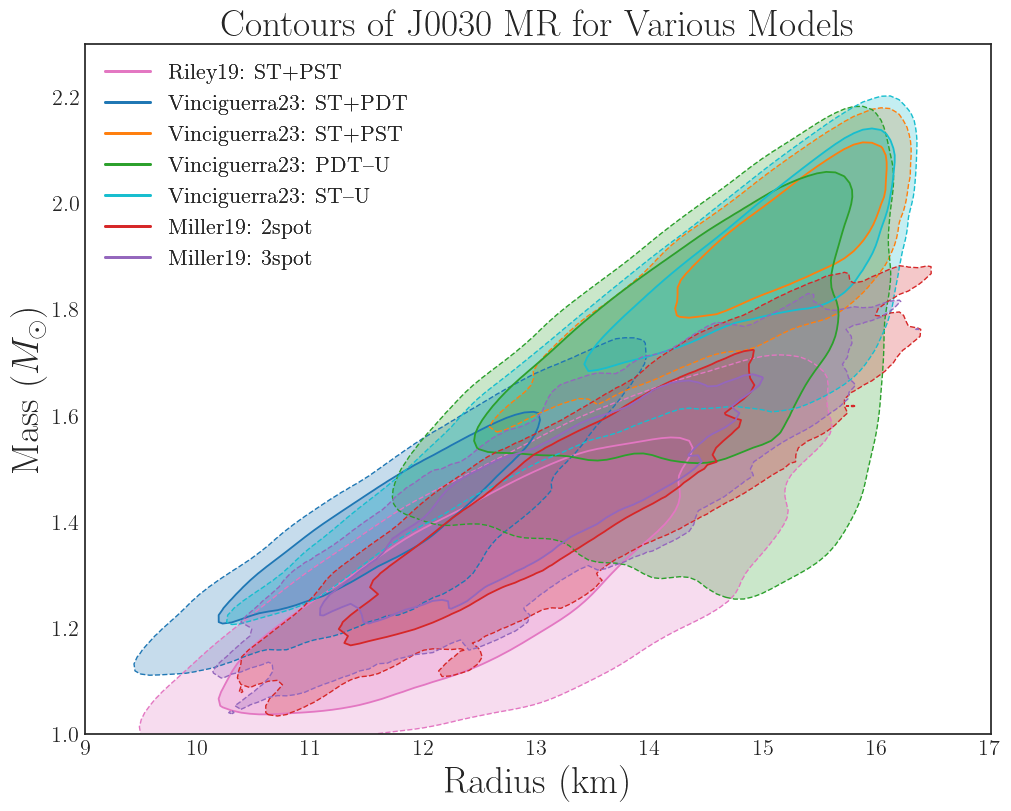

In [2]:
# Plotting
plt.style.use('seaborn-v0_8-white')
fontsize = 27
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
series = [
    ('ST_PST19', 'tab:pink', 'Riley19: ST+PST'),
    ('ST_PDT', 'tab:blue', 'Vinciguerra23: ST+PDT'),
    ('ST_PST', 'tab:orange', 'Vinciguerra23: ST+PST'),
    ('PDT_U', 'tab:green', 'Vinciguerra23: PDT--U'),
    ('ST_U', 'tab:cyan', 'Vinciguerra23: ST--U'),
    ('2spot', 'tab:red', 'Miller19: 2spot'),
    ('3spot', 'tab:purple', 'Miller19: 3spot'),
]

# Function to get density levels that enclose given probability mass (highest-density regions)
def compute_hdr_levels(density_grid, cred_levels=(0.68, 0.95)):
    vals = np.ravel(density_grid)
    sort_idx = np.argsort(vals)[::-1]
    sorted_vals = vals[sort_idx]
    cdf = np.cumsum(sorted_vals)
    cdf /= cdf[-1]
    levels = []
    for cl in cred_levels:
        # threshold where cumulative mass first exceeds cl
        idx = np.searchsorted(cdf, cl)
        levels.append(sorted_vals[idx])
    return levels

handles = []
for key, color, label in series:
    density = KDE_grid_values[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Ensure levels are ascending for contourf
    levels = [lvl95, lvl68, density.max()]

    # Filled contours for 95% and 68%
    cf = ax.contourf(
        R_grid, M_grid, density,
        levels=levels,
        colors=[mpl.colors.to_rgba(color, 0.25), mpl.colors.to_rgba(color, 0.45)],
        antialiased=True
    )

    # Line contours on top for crisp edges
    ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=[color, color],
        linewidths=[1.0, 1.3],
        linestyles=['--', '-']
    )

    # Dummy handle for legend with both 68/95 semantics represented once globally
    handle = mpl.lines.Line2D([], [], color=color, linewidth=2)
    handles.append((label, handle))

# Compose legend: one per dataset for color, plus a separate legend for credibility levels
legend1 = ax.legend([h for _, h in handles], [l for l, _ in handles], fontsize=16, loc='upper left')
ax.add_artist(legend1)

legend_lines = [
    mpl.lines.Line2D([], [], color='black', linestyle='-', linewidth=1.8, label='68% HDR'),
    mpl.lines.Line2D([], [], color='black', linestyle='--', linewidth=1.0, label='95% HDR'),
]

ax.set_xlabel('Radius (km)', fontsize=fontsize)
ax.set_ylabel('Mass ($M_\\odot$)', fontsize=fontsize)
ax.set_title('Contours of J0030 MR for Various Models', fontsize=27)

# Optional: nicer axes limits and minor ticks
ax.set_xlim(R_grid.min(), R_grid.max())
ax.set_ylim(M_grid.min(), M_grid.max())
ax.minorticks_on()
ax.tick_params(which='both', top=True, right=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

# Save avg mean and avg std devs
individuals_M_mu = sum(M_mu.values())/len(M_mu)
individuals_R_mu = sum(R_mu.values())/len(R_mu)
individuals_M_sigma = sum(M_sigma.values())/len(M_sigma)
individuals_R_sigma = sum(R_sigma.values())/len(R_sigma)

# Save plot as png
fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDEVariousmodels.png', dpi=300)


# Combination

In [60]:
R_scale = 5
M_scale = 1

def f_bad_2d(R, R_mu, M, M_mu):
    return norm.pdf(R, loc=R_mu, scale=R_scale) * norm.pdf(M, loc=M_mu, scale=M_scale)

# f_good is the original KDE

# Flat prior and empty grid for posterior
flat_prior = np.linspace(0, 1, 100)
posterior_2d = np.zeros(R_mesh.shape)

# Compute posterior
for i in range(R_mesh.shape[0]):
    for j in range(R_mesh.shape[1]):
        R_val, M_val = R_mesh[i, j], M_mesh[i, j]
        L_p = np.ones_like(flat_prior)
        for name in KDEs_2D:
            f_bad_val = f_bad_2d(R_val, R_mu[name], M_val, M_mu[name])
            f_good_val = KDE_grid_values[name][i, j]
            L_p *= (flat_prior * f_good_val + (1 - flat_prior) * f_bad_val) 
        posterior_2d[i, j] = np.trapz(L_p, flat_prior)

# Normalize
Z = np.trapz(np.trapz(posterior_2d, R_grid, axis=1), M_grid)
posterior_2d /= Z

/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/2192328911.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior_2d[i, j] = np.trapz(L_p, flat_prior)
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/2192328911.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(np.trapz(posterior_2d, R_grid, axis=1), M_grid)


In [61]:
# # PLOT
# plt.figure(figsize=(8, 6))
# plt.contourf(R_grid, M_grid, posterior_2d, cmap='viridis', levels=30)
# plt.xlabel("Radius [km]", fontsize=24)
# plt.xticks(fontsize=16)
# plt.ylabel("Mass [$M_\\odot$]", fontsize=24)
# plt.xticks(fontsize=16)
# plt.title("J0030 MR Posterior from Bayesian Combination", fontsize=22)
# plt.colorbar(label="Density")
# plt.show()

# # Save plot as png
# fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDEPosterior.png', dpi=300)

# Combination Compared to Input Models

In [62]:
# CONVERT POSTERIOR TO 10,000 SAMPLES AND SAVE AS .TXT
R_flat = R_mesh.ravel()
M_flat = M_mesh.ravel()
posterior_flat = posterior_2d.ravel()

# Create (R, M) samples weighted by the posterior
num_samples = 40000
weights = posterior_flat / np.sum(posterior_flat)

# Sample indices from the flattened grid based on the posterior probabilities
sample_indices = np.random.choice(len(R_flat), size=num_samples, p=weights)

sampled_R = R_flat[sample_indices]
sampled_M = M_flat[sample_indices]

combo_R_sigma = np.std(sampled_R)
combo_M_sigma = np.std(sampled_M)

R_mu['posterior'] = np.mean(sampled_R)
M_mu['posterior'] = np.mean(sampled_M)

print(f"Combined Posterior: Median in R: {round(np.median(sampled_R), 4)}^{{+{round(np.percentile(sampled_R, 84)-np.median(sampled_R), 4)}}}_{{-{round(np.median(sampled_R)-np.percentile(sampled_R, 16), 4)}}}")
print(f"Combined Posterior: Median in M: {round(np.median(sampled_M), 4)}^{{+{round(np.percentile(sampled_M, 84)-np.median(sampled_M), 4)}}}_{{-{round(np.median(sampled_M)-np.percentile(sampled_M, 16), 4)}}}")

# Save Mass, Radius format
samples = np.column_stack([sampled_M, sampled_R])
np.savetxt("/Users/ryanoconnor/Desktop/NeutronStarStuff/combined_posterior_samples.txt", samples, fmt="%.6f", header="Radius    Mass")

print("Saved posterior samples to 'combined_posterior_samples.txt'")

Combined Posterior: Median in R: 13.0404^{+0.8889}_{-0.8081}
Combined Posterior: Median in M: 1.4333^{+0.1182}_{-0.1182}
Saved posterior samples to 'combined_posterior_samples.txt'


In [63]:
# Append posterior to data_files
data_files.append(('posterior', '/Users/ryanoconnor/Desktop/NeutronStarStuff/combined_posterior_samples.txt'))
datasets = {}
KDEs_2D = {}

for name, filename in data_files:
    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]
    values = np.vstack([R, M])  # shape (2, N)
    datasets[name] = values
    KDEs_2D[name] = gaussian_kde(values, bw_method='silverman')

# Set up 2D grid for Radius (x) and Mass (y)
R_grid = np.linspace(9, 17, 100)
M_grid = np.linspace(1.0, 2.3, 100)
R_mesh, M_mesh = np.meshgrid(R_grid, M_grid)
coords = np.vstack([R_mesh.ravel(), M_mesh.ravel()])  # shape (2, N_points)

# Precompute KDE values
KDE_grid_values = {}
for name in KDEs_2D:
    KDE_grid_values[name] = KDEs_2D[name].evaluate(coords).reshape(R_mesh.shape)

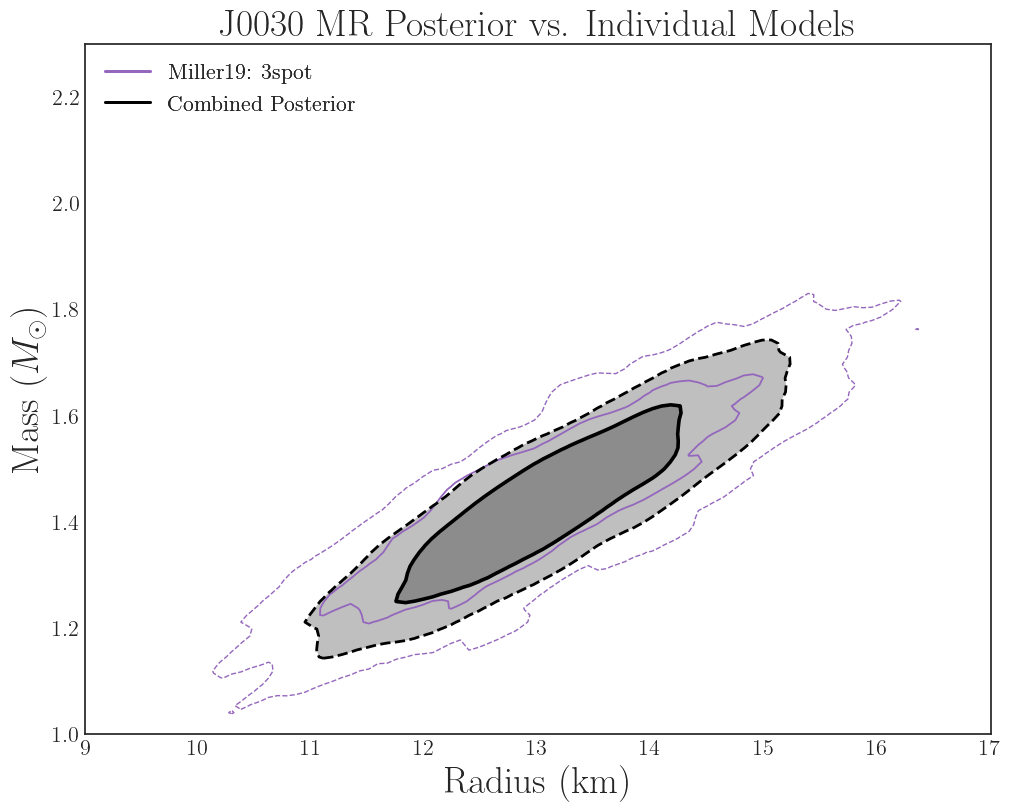

Combo std dev in R: 0.870676140046833
Combo std dev in M: 0.12019242581579276
Individuals avg std dev in R: 1.2008961357397223
Individuals avg std dev in M: 0.1580649948672288
Individuals avg mean R: 13.21688764948025
Individuals avg mean M: 1.4462026430305


In [ ]:
# Plotting
plt.style.use('seaborn-v0_8-white')
fontsize = 27
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Define colors and labels mapped to keys in KDE_grid_values
series = [
    ('ST_PST19', 'tab:pink', 'Riley19: ST+PST'),
    ('ST_PDT', 'tab:blue', 'Vinciguerra23: ST+PDT'),
    ('ST_PST', 'tab:orange', 'Vinciguerra23: ST+PST'),
    ('PDT_U', 'tab:green', 'Vinciguerra23: PDT--U'),
    ('ST_U', 'tab:cyan', 'Vinciguerra23: ST--U'),
    ('2spot', 'tab:red', 'Miller19: 2spot'),
    ('3spot', 'tab:purple', 'Miller19: 3spot'),
    ('posterior', 'black', 'Combined Posterior')
]

# Function to get density levels that enclose given probability mass (highest-density regions)
def compute_hdr_levels(density_grid, cred_levels=(0.68, 0.95)):
    vals = np.ravel(density_grid)
    sort_idx = np.argsort(vals)[::-1]
    sorted_vals = vals[sort_idx]
    cdf = np.cumsum(sorted_vals)
    cdf /= cdf[-1]
    levels = []
    for cl in cred_levels:
        # threshold where cumulative mass first exceeds cl
        idx = np.searchsorted(cdf, cl)
        levels.append(sorted_vals[idx])
    return levels

handles = []
for key, color, label in series:
    density = KDE_grid_values[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Ensure levels are ascending for contourf
    levels = [lvl95, lvl68, density.max()]

    if label == 'Combined Posterior':
        ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=[color, color],
        linewidths=[2.0, 2.6],
        linestyles=['--', '-']
        )
        cf = ax.contourf(
        R_grid, M_grid, density,
        levels=levels,
        colors=[mpl.colors.to_rgba(color, 0.25), mpl.colors.to_rgba(color, 0.45)],
        antialiased=True
        )
    else:
        ax.contour(
            R_grid, M_grid, density,
            levels=[lvl95, lvl68],
            colors=[color, color],
            linewidths=[1.0, 1.3],
            linestyles=['--', '-']
        )

    # Dummy handle for legend with both 68/95 semantics represented once globally
    handle = mpl.lines.Line2D([], [], color=color, linewidth=2)
    handles.append((label, handle))

# Compose legend: one per dataset for color, plus a separate legend for credibility levels
legend1 = ax.legend([h for _, h in handles], [l for l, _ in handles], fontsize=16, loc='upper left')
ax.add_artist(legend1)

legend_lines = [
    mpl.lines.Line2D([], [], color='black', linestyle='-', linewidth=1.8, label='68% HDR'),
    mpl.lines.Line2D([], [], color='black', linestyle='--', linewidth=1.0, label='95% HDR'),
]

ax.set_xlabel('Radius (km)', fontsize=fontsize)
ax.set_ylabel('Mass ($M_\\odot$)', fontsize=fontsize)
ax.set_title('J0030 MR Posterior vs. Individual Models', fontsize=27)

# Optional: nicer axes limits and minor ticks
ax.set_xlim(R_grid.min(), R_grid.max())
ax.set_ylim(M_grid.min(), M_grid.max())
ax.minorticks_on()
ax.tick_params(which='both', top=True, right=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

# Compare std dev and means of combo vs individuals
print(f"Combo std dev in R: {combo_R_sigma}")
print(f"Combo std dev in M: {combo_M_sigma}")
#print(f"Combo mean R: {combo_mean_R}")
#print(f"Combo mean M: {combo_M_mu}")

print(f"Individuals avg std dev in R: {individuals_R_sigma}")
print(f"Individuals avg std dev in M: {individuals_M_sigma}")
print(f"Individuals avg mean R: {individuals_R_mu}")
print(f"Individuals avg mean M: {individuals_M_mu}")

# Save plot as png
fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDEPosteriorvsIndividual.png', dpi=300)


NameError: name 'legend_elements' is not defined

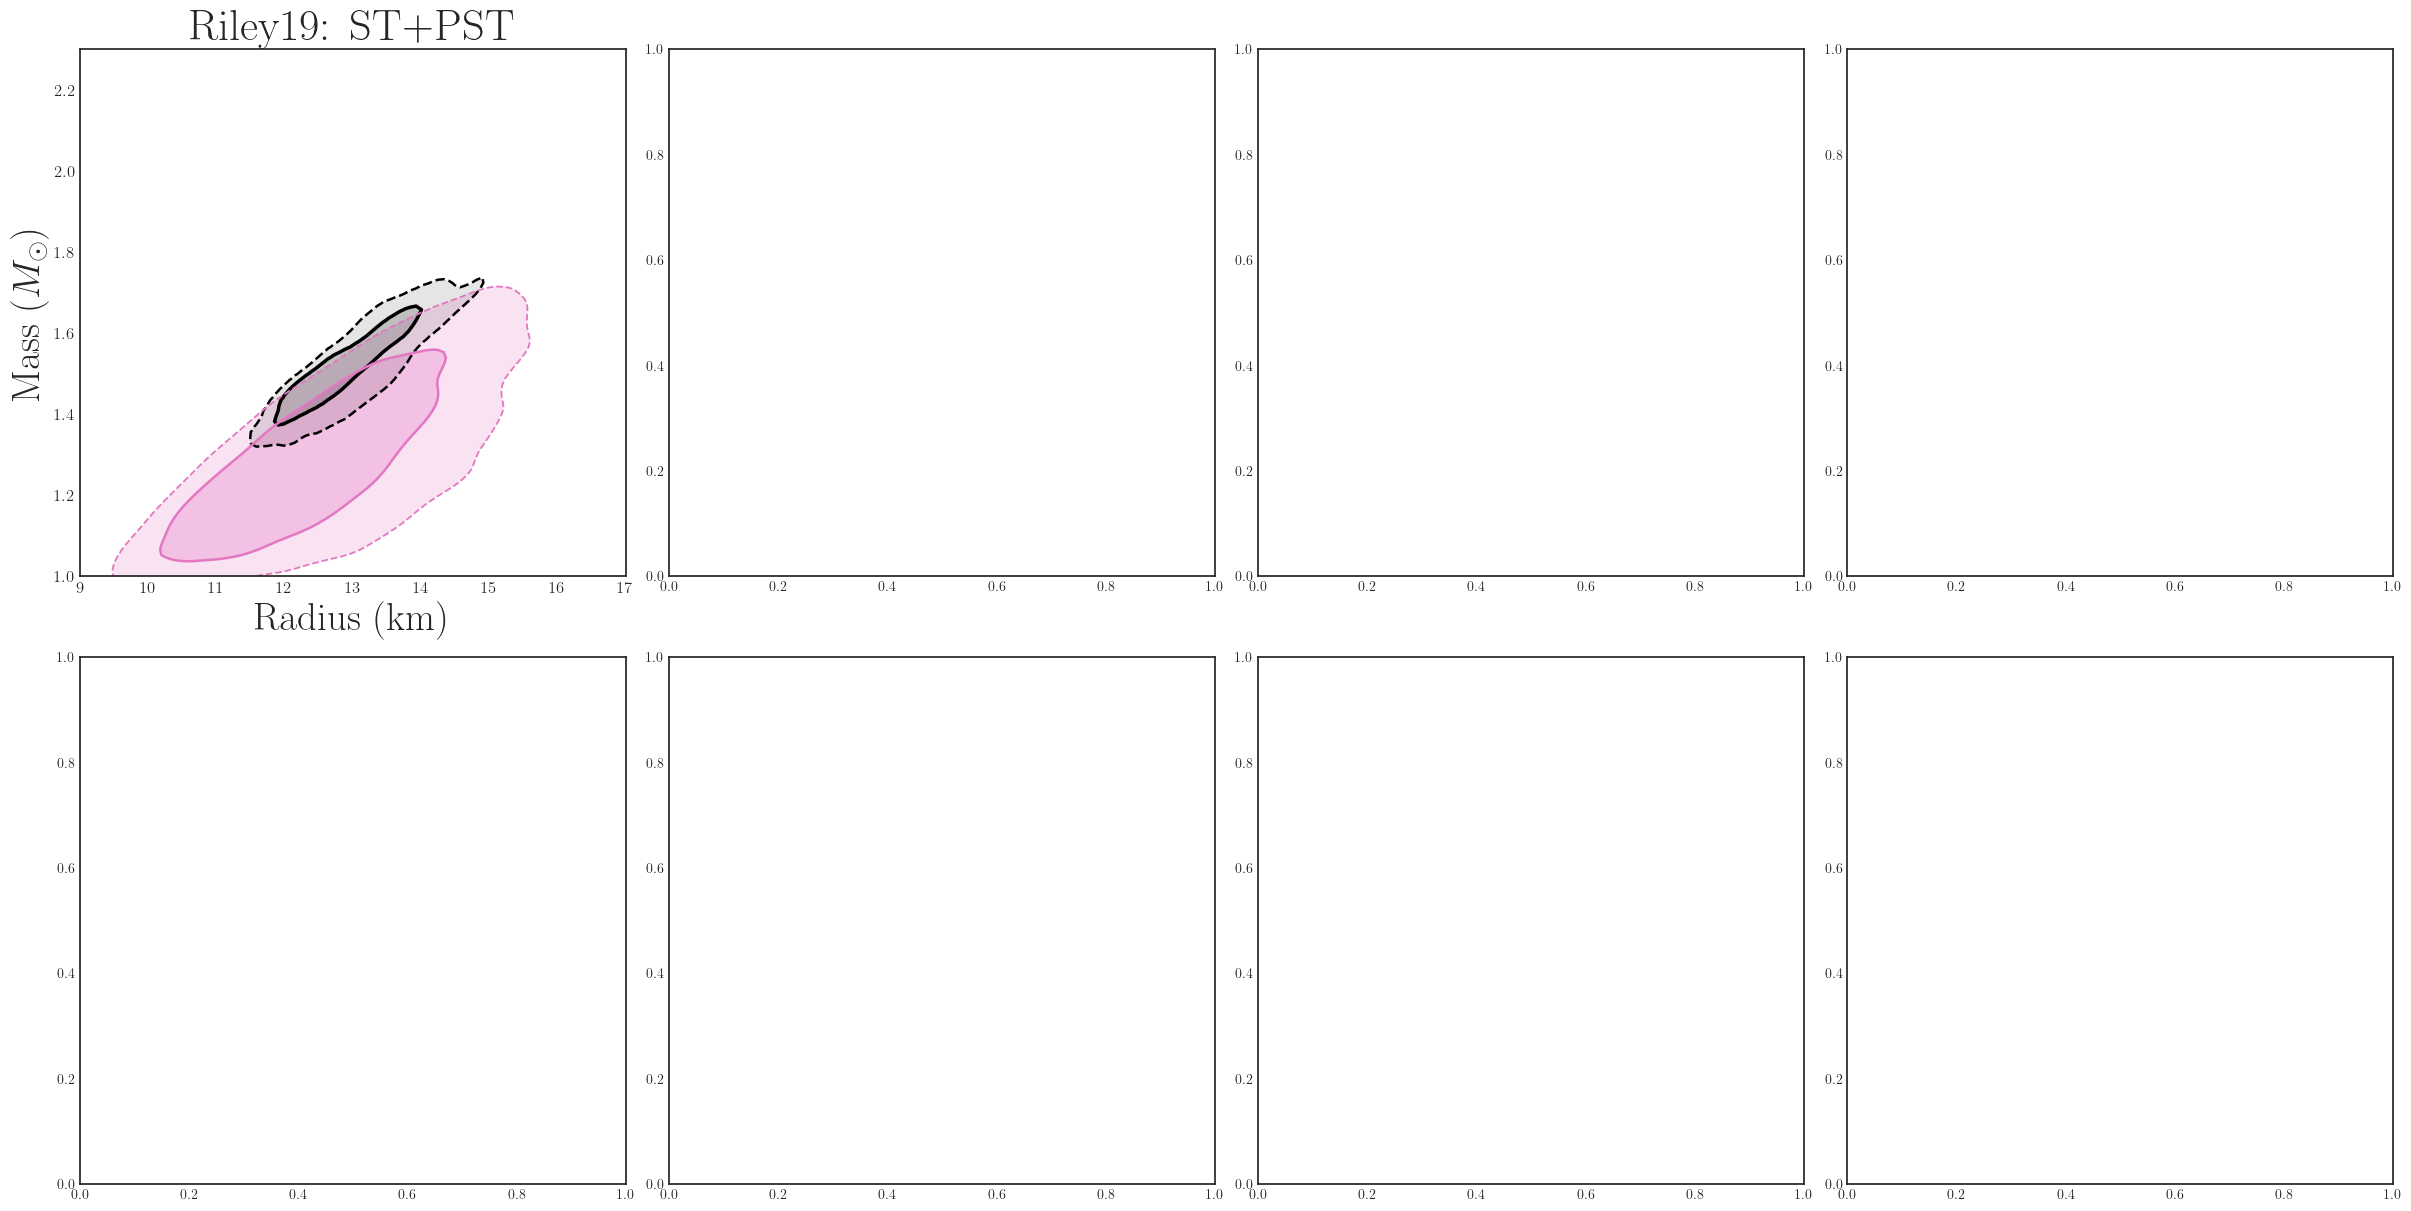

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

plt.style.use('seaborn-v0_8-white')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Extract combined posterior
posterior = KDE_grid_values['posterior']
posterior_lvl68, posterior_lvl95 = compute_hdr_levels(posterior, (0.68, 0.95))

# List of 7 individual datasets (skip posterior)
compare_series = [s for s in series if s[0] != 'posterior']

# 2 × 4 layout
fig, axes = plt.subplots(2, 4, figsize=(24, 12), constrained_layout=True)

def rgba(color, alpha):
    return mpl.colors.to_rgba(color, alpha)

# --- Panels 1–7 ---
for ax, (key, color, label) in zip(axes.flatten()[:7], compare_series):

    density = KDE_grid_values[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Filled individual model
    ax.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(color, 0.20), rgba(color, 0.45)],
        antialiased=True
    )

    # Filled posterior
    ax.contourf(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
        colors=[rgba("black", 0.10), rgba("black", 0.25)],
        antialiased=True
    )

    # Posterior outlines
    ax.contour(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68],
        colors=['black', 'black'],
        linewidths=[1.8, 2.5],
        linestyles=['--', '-']
    )

    # Individual outlines
    ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=[color, color],
        linewidths=[1.3, 1.8],
        linestyles=['--', '-']
    )

    # Title & axes labels
    ax.set_title(label, fontsize=32)
    ax.set_xlabel("Radius (km)", fontsize=28)
    ax.set_ylabel("Mass ($M_\\odot$)", fontsize=28)
    ax.minorticks_on()
    ax.tick_params(labelsize=12)

    # --- Add legend for each panel ---
    indiv_legend = mpl.lines.Line2D([], [], color=color, linewidth=2,
                                    label=f"{label} (68/95%)")
    ax.legend(
        handles=[indiv_legend] + legend_elements,
        fontsize=14,
        loc='upper left',
        frameon=True,
        fancybox=True,
        framealpha=0.75
    )

# --- Panel 8 (All Models vs Posterior) ---
ax_all = axes.flatten()[7]

# All models pale
for key, color, label in compare_series:
    density = KDE_grid_values[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    ax_all.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(color, 0.05), rgba(color, 0.12)],
        antialiased=True
    )

    ax_all.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=[color, color],
        linewidths=[0.8, 1.1],
        linestyles=['--', '-']
    )

# Posterior shading
ax_all.contourf(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
    colors=[rgba("black", 0.10), rgba("black", 0.25)],
    antialiased=True
)

# Posterior outline
ax_all.contour(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68],
    colors=['black', 'black'],
    linewidths=[1.8, 2.5],
    linestyles=['--', '-']
)

ax_all.set_title("All Models", fontsize=32)
ax_all.set_xlabel("Radius (km)", fontsize=28)
ax_all.set_ylabel("Mass ($M_\\odot$)", fontsize=28)
ax_all.minorticks_on()
ax_all.tick_params(labelsize=12)

# Legend for panel 8
multi_handles = [
    mpl.lines.Line2D([], [], color='black', linewidth=2, label='Posterior'),
]
for key, color, label in compare_series:
    multi_handles.append(
        mpl.lines.Line2D([], [], color=color, linewidth=2, label=label)
    )

ax_all.legend(
    handles=multi_handles,
    fontsize=12,
    loc='upper left',
    frameon=True,
    fancybox=True,
    framealpha=0.85,
    ncol=1
)

# Global title
fig.suptitle("Model M--R Posteriors Compared to Bayesian Combination", fontsize=48)

fig.savefig(
    "/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/2x4PosteriorvsIndividual_withLegends.png",
    dpi=300
)

plt.show()

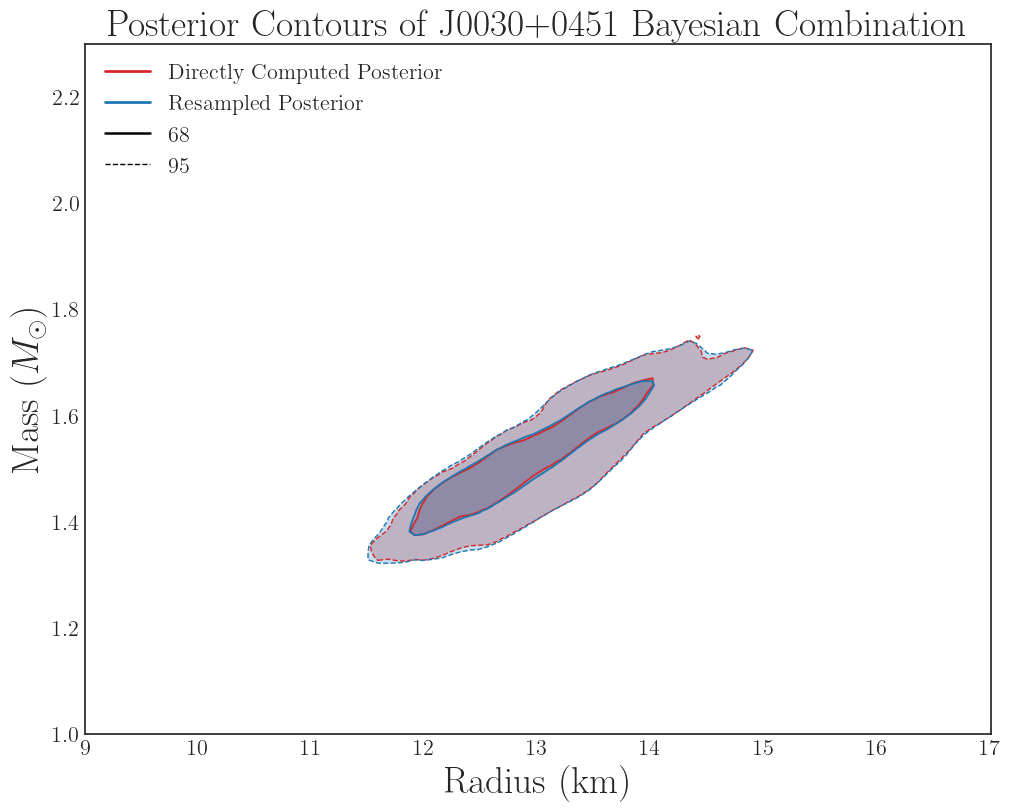

In [ ]:
# Posterior KDE directly from Bayesian combination
direct_posterior_2d = posterior_2d  # Do NOT ravel here

# Posterior as drawn from 40,000 sample points
posterior_data = np.loadtxt('/Users/ryanoconnor/Desktop/NeutronStarStuff/combined_posterior_samples.txt')
posterior_M, posterior_R = posterior_data.T[0], posterior_data.T[1]
posterior_values = np.vstack([posterior_R, posterior_M])  # shape (2, N)
posterior_KDE_2D = gaussian_kde(posterior_values, bw_method='silverman')
posterior_KDE_grid = posterior_KDE_2D.evaluate(coords).reshape(R_mesh.shape)

# Plotting
plt.style.use('seaborn-v0_8-white')
fontsize = 27
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Compute HDR levels for each KDE
def compute_hdr_levels(density_grid, cred_levels=(0.68, 0.95)):
    vals = np.ravel(density_grid)
    sort_idx = np.argsort(vals)[::-1]
    sorted_vals = vals[sort_idx]
    cdf = np.cumsum(sorted_vals)
    cdf /= cdf[-1]
    levels = []
    for cl in cred_levels:
        idx = np.searchsorted(cdf, cl)
        levels.append(sorted_vals[idx])
    return levels

# Direct posterior (array)
levels_direct = sorted([*compute_hdr_levels(direct_posterior_2d), direct_posterior_2d.max()])
cf1 = ax.contourf(
    R_grid, M_grid, direct_posterior_2d,
    levels=levels_direct,
    colors=[mpl.colors.to_rgba('tab:red', 0.25), mpl.colors.to_rgba('tab:red', 0.45)],
    antialiased=True
)
ax.contour(
    R_grid, M_grid, direct_posterior_2d,
    levels=sorted(compute_hdr_levels(direct_posterior_2d)),
    colors=['tab:red', 'tab:red'],
    linewidths=[1.0, 1.3],
    linestyles=['--', '-']
)

# Sampled posterior KDE
levels_sampled = sorted([*compute_hdr_levels(posterior_KDE_grid), posterior_KDE_grid.max()])
cf2 = ax.contourf(
    R_grid, M_grid, posterior_KDE_grid,
    levels=levels_sampled,
    colors=[mpl.colors.to_rgba('tab:blue', 0.25), mpl.colors.to_rgba('tab:blue', 0.45)],
    antialiased=True
)
ax.contour(
    R_grid, M_grid, posterior_KDE_grid,
    levels=sorted(compute_hdr_levels(posterior_KDE_grid)),
    colors=['tab:blue', 'tab:blue'],
    linewidths=[1.0, 1.3],
    linestyles=['--', '-']
)

# Legend handles
handles = [
    mpl.lines.Line2D([], [], color='tab:red', linewidth=2, label='Directly Computed Posterior'),
    mpl.lines.Line2D([], [], color='tab:blue', linewidth=2, label='Resampled Posterior'),
    mpl.lines.Line2D([], [], color='black', linestyle='-', linewidth=1.8, label='68% HDR'),
    mpl.lines.Line2D([], [], color='black', linestyle='--', linewidth=1.0, label='95% HDR'),
]
ax.legend(handles=handles, fontsize=16, loc='upper left')

ax.set_xlabel('Radius (km)', fontsize=fontsize)
ax.set_ylabel('Mass ($M_\\odot$)', fontsize=fontsize)
ax.set_title('Posterior Contours of J0030+0451 Bayesian Combination', fontsize=27)
ax.set_xlim(R_grid.min(), R_grid.max())
ax.set_ylim(M_grid.min(), M_grid.max())
ax.minorticks_on()
ax.tick_params(which='both', top=True, right=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()


# Save plot as png
fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/DirectvsSampledPosterior.png', dpi=300)

<>:39: SyntaxWarning: invalid escape sequence '\%'
<>:51: SyntaxWarning: invalid escape sequence '\%'
<>:39: SyntaxWarning: invalid escape sequence '\%'
<>:51: SyntaxWarning: invalid escape sequence '\%'
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/3854012200.py:39: SyntaxWarning: invalid escape sequence '\%'
  label=f'{quantile_values[i]*100}\%: {i+1}: {q:.2f} km')
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/3854012200.py:51: SyntaxWarning: invalid escape sequence '\%'
  label=f'{quantile_values[i]*100}\%: {q:.2f} $M_\\odot$')
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/3854012200.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_R = np.trapz(posterior_2d, M_grid, axis=0)
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/3854012200.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the 

Peak at R = 12.72 km, density = 0.6005
Peak at R = 13.28 km, density = 0.5301
Peak of P_M is at M = 1.47 M_sun with density 4.7350


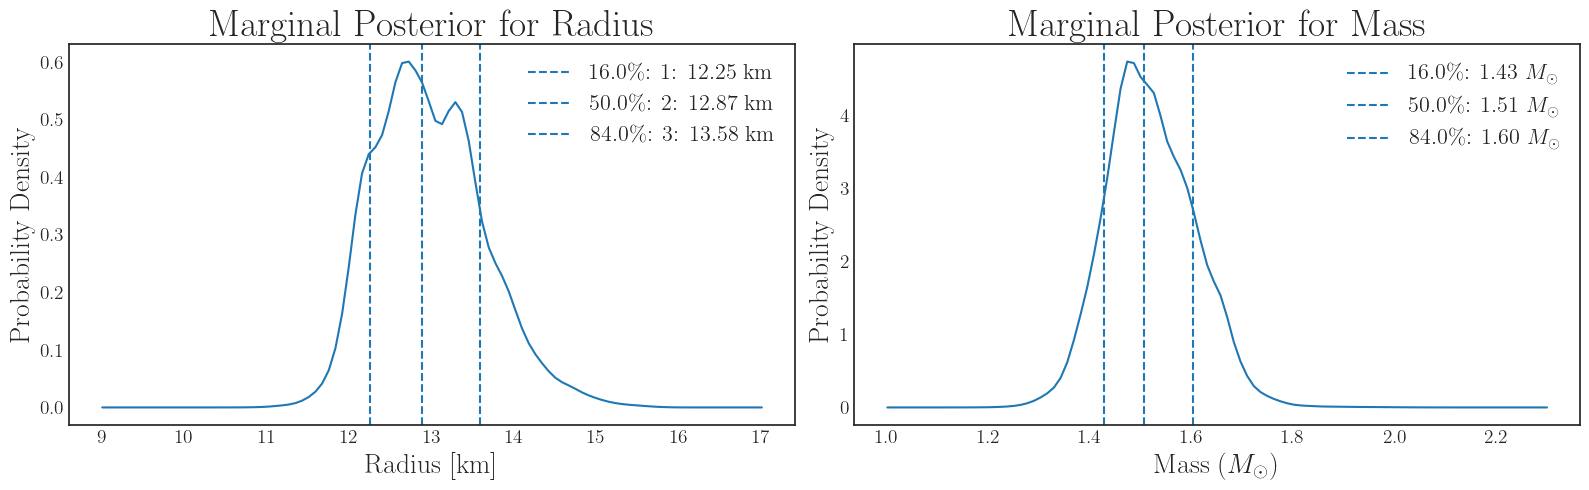

In [ ]:
# Marginal Posteriors

# P(R): integrate over Mass (axis=0 because Mass is rows)
P_R = np.trapz(posterior_2d, M_grid, axis=0)

# P(M): integrate over Radius (axis=1 because Radius is columns)
P_M = np.trapz(posterior_2d, R_grid, axis=1)

P_R /= np.trapz(P_R, R_grid)
from scipy.signal import find_peaks

# Find all local maxima
peaks, _ = find_peaks(P_R)
peak_Rs = R_grid[peaks]
peak_values = P_R[peaks]
for r, v in zip(peak_Rs, peak_values):
    print(f"Peak at R = {r:.2f} km, density = {v:.4f}")

P_M /= np.trapz(P_M, M_grid)

# Find the index of the peak
peak_idx = np.argmax(P_M)
# Get the corresponding radius value
peak_M = M_grid[peak_idx]
print(f"Peak of P_M is at M = {peak_M:.2f} M_sun with density {P_M[peak_idx]:.4f}")

#Quantiles 
quantile_values = [0.16, 0.5, 0.84]
R_quantiles = np.interp(quantile_values, np.cumsum(P_R) * np.diff(np.concatenate(([0], R_grid))), R_grid)
M_quantiles = np.interp(quantile_values, np.cumsum(P_M) * np.diff(np.concatenate(([0], M_grid))), M_grid)

# Set figure size 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#Radius with qauantiles
axes[0].plot(R_grid, P_R)
for i, q in enumerate(R_quantiles):
    axes[0].axvline(q, color='tab:blue', linestyle='--', 
                    label=f'{quantile_values[i]*100}\%: {i+1}: {q:.2f} km')
axes[0].set_xlabel("Radius [km]", fontsize=20)
axes[0].set_ylabel("Probability Density", fontsize=20)
axes[0].set_title("Marginal Posterior for Radius", fontsize=27)
axes[0].legend(loc='upper left')   # Move legend to upper left
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(fontsize=16, loc='upper right')

#Mass
axes[1].plot(M_grid, P_M)
for i, q in enumerate(M_quantiles):
    axes[1].axvline(q, color='tab:blue', linestyle='--', 
                label=f'{quantile_values[i]*100}\%: {q:.2f} $M_\\odot$')
axes[1].set_xlabel("Mass ($M_\\odot$)", fontsize=20)
axes[1].set_ylabel("Probability Density", fontsize=20)
axes[1].set_title("Marginal Posterior for Mass", fontsize=27)
axes[1].legend(loc='upper left')   # Move legend to upper left
axes[1].tick_params(axis='both', labelsize=14)
axes[1].legend(fontsize=16, loc='upper right')

plt.tight_layout()
plt.show()

# Save plot as png
fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/MarginalPosteriors.png', dpi=300)

In [ ]:
import seaborn as sns

# Make seaborn/matplotlib styling consistent with other notebook plots
plt.style.use('seaborn-v0_8-white')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fontsize = 27
label_fs = 20
tick_fs = 16

# Create a JointGrid with NO scatter points — contours only
g = sns.JointGrid(height=8, space=0)

# --- Zoom window settings ---
zoom_R_min, zoom_R_max = 11.0, 16.0
zoom_M_min, zoom_M_max = 1.2, 2.0

# Ensure axes use the zoomed ranges
g.ax_joint.set_xlim(zoom_R_min, zoom_R_max)
g.ax_joint.set_ylim(zoom_M_min, zoom_M_max)
# Also set marginal axes to the same ranges so marginals line up with zoom
g.ax_marg_x.set_xlim(zoom_R_min, zoom_R_max)
g.ax_marg_y.set_ylim(zoom_M_min, zoom_M_max)

# Overlay the direct posterior (grid) as filled HDR contours on the joint axis
def compute_hdr_levels(density_grid, cred_levels=(0.68, 0.95)):
    vals = np.ravel(density_grid)
    sort_idx = np.argsort(vals)[::-1]
    sorted_vals = vals[sort_idx]
    cdf = np.cumsum(sorted_vals)
    cdf /= cdf[-1]
    levels = []
    for cl in cred_levels:
        idx = np.searchsorted(cdf, cl)
        levels.append(sorted_vals[idx])
    return levels

lvl68, lvl95 = compute_hdr_levels(posterior_2d, (0.68, 0.95))
levels = [lvl95, lvl68, posterior_2d.max()]

# Draw filled posterior contours and outlines on joint axis
cf = g.ax_joint.contourf(R_grid, M_grid, posterior_2d, levels=levels,
                         colors=[mpl.colors.to_rgba('black', 0.12), mpl.colors.to_rgba('black', 0.28)],
                         antialiased=True)

g.ax_joint.contour(R_grid, M_grid, posterior_2d, levels=[lvl95, lvl68],
                   colors=['black', 'black'], linewidths=[1.0, 1.6], linestyles=['--', '-'])

# Replace marginals with the computed marginals P_R and P_M

# P(R): integrate over Mass (axis=0 because Mass is rows)
P_R = np.trapz(posterior_2d, M_grid, axis=0)

# P(M): integrate over Radius (axis=1 because Radius is columns)
P_M = np.trapz(posterior_2d, R_grid, axis=1)

P_R /= np.trapz(P_R, R_grid)
from scipy.signal import find_peaks

# Find all local maxima
peaks, _ = find_peaks(P_R)
peak_Rs = R_grid[peaks]
peak_values = P_R[peaks]
for r, v in zip(peak_Rs, peak_values):
    print(f"Peak at R = {r:.2f} km, density = {v:.4f}")

P_M /= np.trapz(P_M, M_grid)

g.ax_marg_x.plot(R_grid, P_R, color='black', lw=2)
g.ax_marg_x.fill_between(R_grid, P_R, color='black', alpha=0.25)
g.ax_marg_x.set_xlabel('')

g.ax_marg_y.plot(P_M, M_grid, color='black', lw=2)
g.ax_marg_y.fill_betweenx(M_grid, P_M, color='black', alpha=0.25)
g.ax_marg_y.set_ylabel('')

# Styling: tick sizes and labels to match other figures
g.ax_joint.tick_params(labelsize=tick_fs, which='both', top=True, right=True)
g.ax_marg_x.tick_params(labelsize=tick_fs-2)
g.ax_marg_y.tick_params(labelsize=tick_fs-2)
# Save joint contours-only plot
g.fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/JointPlot.png', dpi=300)

plt.close(g.fig)
g.ax_joint.set_xlabel("Radius (km)", fontsize=label_fs)
g.ax_joint.set_ylabel("Mass ($M_\\odot$)", fontsize=label_fs)
g.fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/MarginalPosteriors.png', dpi=300)
plt.suptitle("Combined Posterior (joint) and Marginals", fontsize=fontsize-8)
plt.show()
plt.tight_layout()
plt.subplots_adjust(top=0.93)

g.ax_joint.set_ylabel("Mass ($M_\\odot$)", fontsize=label_fs)
g.fig.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/MarginalPosteriors.png', dpi=300)

plt.suptitle("Combined Posterior (joint) and Marginals", fontsize=fontsize-8)
plt.show()

plt.tight_layout()
plt.subplots_adjust(top=0.93)

/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/872853341.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_R = np.trapz(posterior_2d, M_grid, axis=0)
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/872853341.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_M = np.trapz(posterior_2d, R_grid, axis=1)
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/872853341.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_R /= np.trapz(P_R, R_grid)
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_4877/872853341.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_M /

Peak at R = 12.72 km, density = 0.6005
Peak at R = 13.28 km, density = 0.5301


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

# Recovering a posterior "p" distributiion

In [ ]:
# Score each individual measurement against the posterior
P_vi_1 = {}
epsilon = 1e-300  # Tiny value to avoid divide-by-zero
for name in KDEs_2D:
    # if name == 'posterior':
    #     continue  # Skip the posterior itself
    prob_grid = np.zeros(R_mesh.shape)
    for i in range(R_mesh.shape[0]):
        for j in range(R_mesh.shape[1]):
            R_val, M_val = R_mesh[i, j], M_mesh[i, j]
            f_good = KDE_grid_values[name][i, j]
            f_bad = f_bad_2d(R_val, R_mu[name], M_val, M_mu[name])
            p_term = (flat_prior * f_good) / (flat_prior * f_good + (1 - flat_prior) * f_bad + epsilon)
            prob_grid[i, j] = np.trapz(p_term, flat_prior) * posterior_2d[i, j]
    P_vi_1[name] = np.trapz(np.trapz(prob_grid, R_grid, axis=1), M_grid)
    print(f"Probability of {name} being good: {P_vi_1[name]:.4f}")

Probability of ST_PDT being good: 0.8220
Probability of ST_PST being good: 0.4480
Probability of ST_PST19 being good: 0.7574
Probability of PDT_U being good: 0.8107
Probability of ST_U being good: 0.7216
Probability of 2spot being good: 0.8238
Probability of 3spot being good: 0.8877
Probability of posterior being good: 0.9394


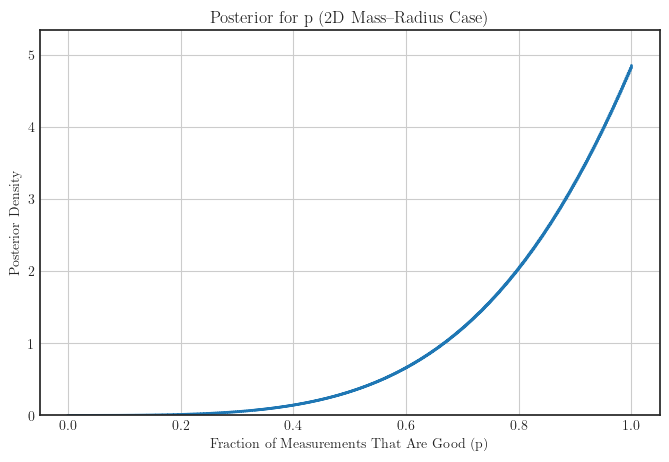

In [ ]:
# Fast marginal posterior over p for 2D case
p_grid = np.linspace(0.00, 1.00, 500)
posterior_p_2D = np.zeros_like(p_grid)

for i, p in enumerate(p_grid):
    joint_likelihood = np.ones(R_mesh.shape)
    for name in KDEs_2D:
        if name == 'posterior':
            continue  # Skip the combined posterior itself
        f_good_vals = KDE_grid_values[name]
        f_bad_vals_2d = f_bad_2d(R_mesh, R_mu[name], M_mesh, M_mu[name])
        f_mix = p * f_good_vals + (1 - p) * f_bad_vals_2d
        joint_likelihood *= f_mix
    
    # Integrate over 2D grid
    posterior_p_2D[i] = np.trapz(np.trapz(joint_likelihood, R_grid, axis=1), M_grid)

# Normalize
posterior_p_2D /= np.trapz(posterior_p_2D, p_grid)

bin_width = p_grid[1] - p_grid[0]
left_edges = p_grid
right_edges = p_grid

# Interleave left and right edges
edges = np.empty(2 * len(p_grid))
edges[0::2] = left_edges
edges[1::2] = right_edges

# Heights (already flat per bin)
heights = np.repeat(posterior_p_2D, 2)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(edges, heights, drawstyle='steps-post', lw=2)
plt.xlabel("Fraction of Measurements That Are Good (p)")
plt.ylabel("Posterior Density")
plt.title("Posterior for p (2D Mass–Radius Case)")
plt.grid(True)
plt.ylim(0, max(heights) * 1.1)
plt.show()

## Plot to Compare Posterior J0030 to other neutron stars

M1: Median in M: 1.5005^{+0.0969}_{-0.0885}
M1: Median in R: 10.7715^{+1.3415}_{-0.9032}
full smoothing factor for M1: 0.2644913097181993
M2: Median in M: 1.2387^{+0.0756}_{-0.0715}
M2: Median in R: 10.7271^{+1.3699}_{-0.858}
full smoothing factor for M2: 0.2644913097181993
J0437: Median in M: 1.4179^{+0.0364}_{-0.0366}
J0437: Median in R: 11.3576^{+0.9429}_{-0.6242}
full smoothing factor for J0437: 0.12884686950421398
posterior: Median in M: 1.5121^{+0.0919}_{-0.0788}
posterior: Median in R: 12.8788^{+0.7273}_{-0.5657}
full smoothing factor for posterior: 0.17099759466766973


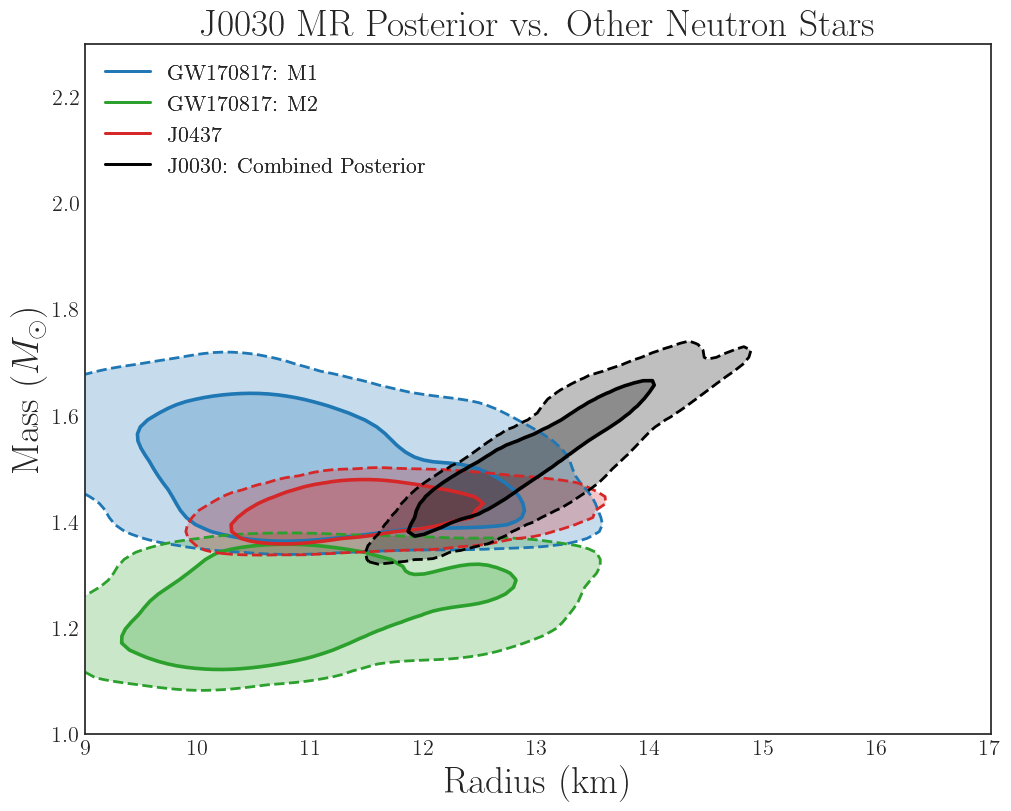

In [ ]:
# Load Data (Mass vs Radius)
data_files = [
    ('M1', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/GW170817_M1'),
    ('M2', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/GW170817_M2'), 
     ('J0437', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/J0437'),
    ('posterior', '/Users/ryanoconnor/Desktop/NeutronStarStuff/combined_posterior_samples.txt')
]

datasets = {}
KDEs_2D = {}
M_sigma = {}
M_mu = {}
R_sigma = {}
R_mu = {}
bw_method = {}
for name, filename in data_files:
    data = np.loadtxt(filename)
    M, R = zip(*data.T[0:2].T)
    M_sigma[name] = (np.std(M))
    M_mu[name] = (np.mean(M))
    print(f"{name}: Median in M: {round(np.median(M), 4)}^{{+{round(np.percentile(M, 84)-np.median(M), 4)}}}_{{-{round(np.median(M)-np.percentile(M, 16), 4)}}}")
    R_sigma[name] = (np.std(R))
    R_mu[name] = (np.mean(R))
    print(f"{name}: Median in R: {round(np.median(R), 4)}^{{+{round(np.percentile(R, 84)-np.median(R), 4)}}}_{{-{round(np.median(R)-np.percentile(R, 16), 4)}}}")
    values = np.vstack([R, M])  # shape (2, N)
    datasets[name] = values
    KDEs_2D[name] = gaussian_kde(values, bw_method='silverman')
    print(f"full smoothing factor for {name}: {KDEs_2D[name].factor}")
    # KDEs_2D[name] = gaussian_kde(values, bw_method=0.1*KDEs_2D[name].factor)
    # print(f"0.1 times smoothing factor for {name}: {KDEs_2D[name].factor}")
    

# Set up 2D grid for Radius (x) and Mass (y)
R_grid = np.linspace(9, 17, 100)
M_grid = np.linspace(1.0, 2.3, 100)
R_mesh, M_mesh = np.meshgrid(R_grid, M_grid)
coords = np.vstack([R_mesh.ravel(), M_mesh.ravel()])  # shape (2, N_points)

# Precompute KDE values
KDE_grid_values = {}
for name in KDEs_2D:
    KDE_grid_values[name] = KDEs_2D[name].evaluate(coords).reshape(R_mesh.shape)

unique_series = [
    ('M1', 'tab:blue', 'GW170817: M1'),
    ('M2', 'tab:green', 'GW170817: M2'),
    ('J0437', 'tab:red', 'J0437'),
    ('posterior', 'black', 'J0030: Combined Posterior')
]

# Function to get density levels that enclose given probability mass (highest-density regions)
def compute_hdr_levels(density_grid, cred_levels=(0.68, 0.95)):
    vals = np.ravel(density_grid)
    sort_idx = np.argsort(vals)[::-1]
    sorted_vals = vals[sort_idx]
    cdf = np.cumsum(sorted_vals)
    cdf /= cdf[-1]
    levels = []
    for cl in cred_levels:
        # threshold where cumulative mass first exceeds cl
        idx = np.searchsorted(cdf, cl)
        levels.append(sorted_vals[idx])
    return levels

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

handles = []
for key, color, label in unique_series:
    density = KDE_grid_values[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Ensure levels are ascending for contourf
    levels = [lvl95, lvl68, density.max()]

    
    ax.contour(
    R_grid, M_grid, density,
    levels=[lvl95, lvl68],
    colors=[color, color],
    linewidths=[2.0, 2.6],
    linestyles=['--', '-']
    )
    cf = ax.contourf(
    R_grid, M_grid, density,
    levels=levels,
    colors=[mpl.colors.to_rgba(color, 0.25), mpl.colors.to_rgba(color, 0.45)],
    antialiased=True
    )

    # Dummy handle for legend with both 68/95 semantics represented once globally
    handle = mpl.lines.Line2D([], [], color=color, linewidth=2)
    handles.append((label, handle))

# Compose legend: one per dataset for color, plus a separate legend for credibility levels
legend1 = ax.legend([h for _, h in handles], [l for l, _ in handles], fontsize=16, loc='upper left')
ax.add_artist(legend1)

legend_lines = [
    mpl.lines.Line2D([], [], color='black', linestyle='-', linewidth=1.8, label='68% HDR'),
    mpl.lines.Line2D([], [], color='black', linestyle='--', linewidth=1.0, label='95% HDR'),
]

ax.set_xlabel('Radius (km)', fontsize=fontsize)
ax.set_ylabel('Mass ($M_\\odot$)', fontsize=fontsize)
ax.set_title('J0030 MR Posterior vs. Other Neutron Stars', fontsize=27)

# Optional: nicer axes limits and minor ticks
ax.set_xlim(R_grid.min(), R_grid.max())
ax.set_ylim(M_grid.min(), M_grid.max())
ax.minorticks_on()
ax.tick_params(which='both', top=True, right=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()